# 도구 (Tools)

도구는 에이전트가 외부 시스템과 상호작용할 수 있게 해주는 핵심 구성 요소입니다. API 호출, 데이터베이스 쿼리, 파일 시스템 접근 등 다양한 작업을 수행할 수 있으며, 잘 정의된 입력과 출력을 통해 모델의 기능을 확장합니다.

도구는 호출 가능한 함수와 입력 스키마를 캡슐화합니다. 호환 가능한 채팅 모델에 전달되면, 모델은 도구를 호출할지 여부와 어떤 인수로 호출할지를 자율적으로 결정합니다. 이를 통해 에이전트는 복잡한 작업을 단계별로 수행할 수 있습니다.

> 참고 문서: [LangChain Tools](https://docs.langchain.com/oss/python/langchain/tools.md)

LangSmith 추적을 시작합니다.
[프로젝트명]
LangChain-V1-Tutorial


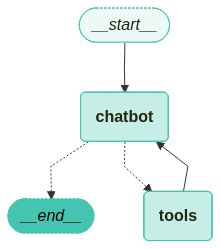

In [1]:
from feature.tools.ToolArgsSetting import ToolArgsSetting, ToolNodeState


graph = ToolArgsSetting()

graph.show_graph()

## 도구 생성

### 기본 도구 정의

도구를 생성하는 가장 간단한 방법은 `@tool` 데코레이터를 사용하는 것입니다. 데코레이터가 적용된 함수는 자동으로 도구로 변환되며, 함수의 docstring이 도구 설명이 됩니다.

**도구 정의 규칙:**
1. `@tool` 데코레이터를 함수에 적용합니다
2. 도구 이름은 함수 이름에서 자동으로 가져옵니다
3. 도구 설명은 함수의 docstring에서 가져옵니다
4. 입력 스키마는 함수의 매개변수와 타입 힌트에서 자동으로 생성됩니다


### 타입 힌트의 중요성

타입 힌트는 도구의 입력 스키마를 정의하므로 필수입니다. 모델은 타입 힌트를 통해 각 매개변수의 타입을 이해하고 올바른 값을 전달합니다. docstring은 모델이 도구의 목적을 이해하는 데 도움이 되므로 정보가 풍부하고 간결해야 합니다.

아래 코드는 데이터베이스 검색 도구를 정의하는 예시입니다.

In [2]:
# 도구 정보 확인
import json
from feature.tools.ToolArgsSetting import search_database

print(f"Tool name: {search_database.name}")
print(f"Tool description: {search_database.description}")
print('-' * 100)

print(json.dumps(search_database.tool_call_schema.model_json_schema(), indent=2, ensure_ascii=False))


Tool name: search_database
Tool description: Search the customer database for records matching the query.

    Args:
        query: Search terms to look for
        limit: Maximum number of results to return
----------------------------------------------------------------------------------------------------
{
  "description": "Search the customer database for records matching the query.\n\nArgs:\n    query: Search terms to look for\n    limit: Maximum number of results to return",
  "properties": {
    "query": {
      "title": "Query",
      "type": "string"
    },
    "limit": {
      "default": 10,
      "title": "Limit",
      "type": "integer"
    }
  },
  "required": [
    "query"
  ],
  "title": "search_database",
  "type": "object"
}


### 커스텀 도구 이름

기본적으로 도구 이름은 함수 이름에서 가져옵니다. 더 설명적인 이름이 필요한 경우 `@tool("커스텀_이름")` 형식으로 재정의할 수 있습니다. 도구 이름은 모델이 어떤 도구를 호출할지 결정하는 데 사용되므로 명확하고 직관적이어야 합니다.

아래 코드는 커스텀 도구 이름을 설정하는 예시입니다.

In [3]:
from feature.tools.ToolArgsSetting import search

print(f"Tool name: {search.name}")
print(f"Tool description: {search.description}")

print('-' * 100)

print(json.dumps(search.tool_call_schema.model_json_schema(), indent=2, ensure_ascii=False))

Tool name: web_search
Tool description: Search the web for information.
----------------------------------------------------------------------------------------------------
{
  "description": "Search the web for information.",
  "properties": {
    "query": {
      "title": "Query",
      "type": "string"
    }
  },
  "required": [
    "query"
  ],
  "title": "web_search",
  "type": "object"
}


### 커스텀 도구 설명

- docString 보다 description 이 우선순위가 높음

더 명확한 모델 가이드를 위해 자동 생성된 도구 설명을 재정의할 수 있습니다. `description` 매개변수를 사용하면 docstring과 별도로 모델에게 전달되는 설명을 지정할 수 있습니다.

좋은 도구 설명은 도구의 목적, 사용 시점, 예상 결과를 명확히 전달해야 합니다.

아래 코드는 커스텀 도구 설명을 설정하는 예시입니다.

In [4]:
from feature.tools.ToolArgsSetting import calc

print(f"Tool name: {calc.name}")
print(f"Tool description: {calc.description}")

print('-' * 100)

print(json.dumps(calc.tool_call_schema.model_json_schema(), indent=2, ensure_ascii=False))

Tool name: calculator
Tool description: Performs arithmetic calculations. Use this for any math problems.
----------------------------------------------------------------------------------------------------
{
  "description": "Performs arithmetic calculations. Use this for any math problems.",
  "properties": {
    "expression": {
      "title": "Expression",
      "type": "string"
    }
  },
  "required": [
    "expression"
  ],
  "title": "calculator",
  "type": "object"
}


### parse_docstring
- docString, description, parse_docstring 의 우선 순위를 파악하고자 함
- description : description이 docString 보다 우선 순위가 높음
- properties : parse_docstring으로 인해 자동으로 생성되는 내용보다 더 풍부해짐

In [5]:
from deep_agents_from_scratch.file_tools import read_file

print(f"Tool name: {read_file.name}")
print(f"Tool description: {read_file.description}")

print('-' * 100)
print(json.dumps(read_file.tool_call_schema.model_json_schema(), indent=2, ensure_ascii=False))

Tool name: read_file
Tool description: Read content from a file in the virtual filesystem with optional pagination.

This tool returns file content with line numbers (like `cat -n`) and supports reading large files in chunks to avoid context overflow.

Parameters:
- file_path (required): Path to the file you want to read
- offset (optional, default=0): Line number to start reading from  
- limit (optional, default=2000): Maximum number of lines to read

Essential before making any edits to understand existing content. Always read a file before editing it.
----------------------------------------------------------------------------------------------------
{
  "description": "Read content from a file in the virtual filesystem with optional pagination.\n\nThis tool returns file content with line numbers (like `cat -n`) and supports reading large files in chunks to avoid context overflow.\n\nParameters:\n- file_path (required): Path to the file you want to read\n- offset (optional, default

---

## Pydantic 모델로 입력 스키마 정의
- parse_docstring vs args_schema (둘 중 하나 쓰면 됨, 동일한 기능임)

복잡한 입력 검증이 필요한 경우 Pydantic 모델을 사용하여 명확한 입력 스키마를 정의할 수 있습니다. `args_schema` 매개변수에 Pydantic 모델을 전달하면, 도구 호출 시 자동으로 입력 검증이 수행됩니다.

Pydantic 모델을 사용하면 다음과 같은 이점이 있습니다:
- 타입 검증 및 변환 자동화
- `Literal` 타입을 통한 허용값 제한
- `Field`의 description을 통한 상세한 매개변수 설명

아래 코드는 Pydantic 모델을 사용한 날씨 조회 도구 예시입니다.

In [6]:
from feature.tools.ToolArgsSetting import get_weather

print(f"Tool name: {get_weather.name}")
print(f"Tool description: {get_weather.description}")

print('-' * 100)
print(json.dumps(get_weather.tool_call_schema.model_json_schema(), indent=2, ensure_ascii=False))

Tool name: get_weather
Tool description: Get current weather and optional forecast.
----------------------------------------------------------------------------------------------------
{
  "description": "Get current weather and optional forecast.",
  "properties": {
    "location": {
      "description": "City name or coordinates",
      "title": "Location",
      "type": "string"
    },
    "units": {
      "default": "celsius",
      "description": "Temperature unit preference",
      "enum": [
        "celsius",
        "fahrenheit"
      ],
      "title": "Units",
      "type": "string"
    },
    "include_forecast": {
      "default": false,
      "description": "Include 5-day forecast",
      "title": "Include Forecast",
      "type": "boolean"
    }
  },
  "required": [
    "location"
  ],
  "title": "get_weather",
  "type": "object"
}


In [7]:
# 도구 테스트
print(
    get_weather.invoke(
        {"location": "Seoul", "units": "celsius", "include_forecast": True}
    )
)

현재 Seoul 지역의 날씨는 22 C 도
다음 5일 날씨: 맑음


In [8]:
# 도구 테스트
print(
    get_weather.invoke(
        {"location": "Seoul", "units": "celsiuss", "include_forecast": True}
    )
)

ValidationError: 1 validation error for WeatherInput
units
  Input should be 'celsius' or 'fahrenheit' [type=literal_error, input_value='celsiuss', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/literal_error

In [ ]:
graph.invoke({"messages": "2025년 LangGraph 사용 사례 알려주세요."})


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_dsT3Ggs7fm49SYmkbmtLRf6g)
 Call ID: call_dsT3Ggs7fm49SYmkbmtLRf6g
  Args:
    query: 2025 LangGraph use cases
    time_range: year
    search_depth: advanced

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: tavily_search

{"query": "2025 LangGraph use cases", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://sparkco.ai/blog/mastering-langgraph-state-management-in-2025", "title": "Mastering LangGraph State Management in 2025 - Sparkco AI", "content": "## Conclusion\n\nIn exploring LangGraph state management in 2025, we have uncovered significant advancements in managing complex multi-agent systems effectively. The emphasis is on explicit, reducer-driven state sche

{'messages': [HumanMessage(content='2025년 LangGraph 사용 사례 알려주세요.', additional_kwargs={}, response_metadata={}, id='b8cd2dfc-dce0-4b76-b362-c8f6b50262bc'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1220, 'total_tokens': 1251, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_026a2c69f4', 'id': 'chatcmpl-Devv20yKUqK50RQxucsANdSdpz5kN', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e1fb0-a990-7392-9b87-e5375585a34a-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '2025 LangGraph use cases', 'time_range': 'year', 'search_depth': 'advanced'}, 'id': 'call_dsT3Ggs7fm49SYmkbmtLRf6g', 'type': 'tool_

In [ ]:
graph.stream({"messages": "2025년 LangGraph 사용 사례 알려주세요."})


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "2025 LangGraph use cases", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://sparkco.ai/blog/mastering-langgraph-state-management-in-2025", "title": "Mastering LangGraph State Management in 2025 - Sparkco AI", "content": "## Conclusion\n\nIn exploring LangGraph state management in 2025, we have uncovered significant advancements in managing complex multi-agent systems effectively. The emphasis is on explicit, reducer-driven state schemas, offering a robust foundation for scalable workflows. The precision with which LangGraph handles state transitions through TypedDicts and reducer functions ensures resilience and data integrity, even in parallel execution environments.\n\nThe use of frameworks such as LangChain, AutoGen, and LangGraph plays a critical role in simplifying intricate operations, especiall